<div style="background-color:#00843D;padding:22px 28px;border-radius:12px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Manizales</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 06: El Algoritmo Central de las Neural ODEs
## El metodo adjunto: backpropagation continuo

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Explicar** el estado adjunto $a(t) = \partial L / \partial \mathbf{z}(t)$ y su significado
2. **Identificar** la analogia entre el metodo adjunto y backpropagation discreto
3. **Implementar** el ODESolve forward con RK4 diferenciable en TensorFlow
4. **Implementar** las dinamicas aumentadas del Algoritmo 1 del paper
5. **Entrenar** una Neural ODE real y comparar su uso de memoria con ResNet

---

> Las celdas **[OK]** estan listas con `Shift+Enter`. Las **[Ejercicio]** son para completar.


## 1. ¿A que se asemeja el Algoritmo 1?

El Algoritmo 1 del paper implementa el gradiente de un problema de valor inicial.
Antes de leer el algoritmo, necesitamos responder la pregunta del margen:

**¿A que se asemeja el metodo adjunto?**

Se asemeja a **backpropagation**, pero en tiempo continuo.

Recordemos como funciona backpropagation en una ResNet de $T$ capas:

```
FORWARD (izquierda a derecha):
   x -> [capa 1] -> h_1 -> [capa 2] -> h_2 -> ... -> [capa T] -> y -> L
         (guarda h_1)       (guarda h_2)               (guarda h_T)

BACKWARD (derecha a izquierda):
   dL/dy -> [capa T]^-1 -> dL/dh_{T-1} -> ... -> [capa 1]^-1 -> dL/dx
   (y ademas: dL/dtheta_T,  dL/dtheta_{T-1},  ...,  dL/dtheta_1)
```

Costo de memoria: hay que guardar todas las activaciones $h_1, h_2, \ldots, h_T$.
Para una ResNet profunda, esto puede ser gigabytes.

El metodo adjunto hace lo mismo, pero en continuo:

```
FORWARD (t0 -> t1):
   Resolver  dz/dt = f(z, t, theta)  de t0 a t1
   Guardar solo z(t1)  (estado final)

BACKWARD (t1 -> t0, resolviendo otra EDO hacia atras):
   Resolver el sistema aumentado:
     dz/dt    =  f(z, t, theta)                <- reconstruir z(t) si se necesita
     da/dt    = -a(t)^T * (df/dz)              <- adjunto: el gradiente continuo
     d(dL/dtheta)/dt = -a(t)^T * (df/dtheta)   <- acumular gradiente de pesos
```

**Costo de memoria: O(1).** Solo necesitamos el estado actual del sistema aumentado,
no todas las activaciones intermedias. El solver reconstruye el pasado cuando lo necesita.


## 2. El estado adjunto $a(t)$: el gradiente continuo

El estado adjunto se define como:

$$a(t) = \frac{\partial L}{\partial \mathbf{z}(t)}$$

Es el gradiente de la perdida $L$ con respecto al estado oculto $\mathbf{z}$ en el tiempo $t$.

En backpropagation discreto, pasamos el gradiente $\delta_t = \partial L / \partial h_t$ capa por capa.
El adjunto $a(t)$ es exactamente eso, pero definido de forma continua en el tiempo.

### Sus condiciones iniciales y ecuacion de movimiento

**Condicion inicial** (en $t = t_1$, el tiempo final):

$$a(t_1) = \frac{\partial L}{\partial \mathbf{z}(t_1)}$$

Esto es simplemente el gradiente de la perdida respecto a la salida de la red --
exactamente lo que calcula `tape.gradient(L, z_final)` en TensorFlow.

**Ecuacion de movimiento** (hacia atras en el tiempo):

$$\frac{d a(t)}{dt} = -a(t)^T \frac{\partial f}{\partial \mathbf{z}}$$

donde $\partial f / \partial \mathbf{z}$ es el Jacobiano de la dinamica respecto al estado.

> **Analogia directa con backprop:**
> En backprop discreto: $\delta_{t-1} = \delta_t \cdot W_t^T$ (multiplicar por la transpuesta)
> En el adjunto continuo: $da/dt = -a(t)^T (\partial f / \partial z)$ (misma idea, continua)


## 3. El Algoritmo 1: paso a paso

```
Algoritmo 1: Gradiente en modo reverso de un PVI de EDO

ENTRADA: parametros theta, tiempos t0 y t1,
         estado final z(t1), gradiente de perdida dL/dz(t1)

Paso 1: Definir el estado aumentado inicial s0:
        s0 = [z(t1),  dL/dz(t1),  0_{|theta|}]
              ^------  ^---------  ^-----------
              estado   adjunto     gradiente de pesos
              final    inicial     (empieza en cero)

Paso 2: Definir la dinamica aumentada aug_dynamics(s, t, theta):
        Calcula tres cosas juntas en un solo sistema de EDOs:
          (1)  f(z, t, theta)           <- dinamica de z
          (2) -a(t)^T * (df/dz)        <- dinamica del adjunto
          (3) -a(t)^T * (df/dtheta)    <- acumulacion del gradiente de pesos

Paso 3: Resolver el sistema aumentado HACIA ATRAS:
        ODESolve(s0, aug_dynamics, t_inicio=t1, t_final=t0, theta)

Paso 4: Extraer los gradientes del estado final:
        - z(t0):       el estado inicial reconstruido
        - dL/dz(t0):   gradiente respecto a la entrada
        - dL/dtheta:   gradiente respecto a los pesos (lo que necesita el optimizador)
```

Los **productos vector-Jacobiano** en los pasos (2) y (3) son exactamente
los que calcula TensorFlow con `tape.gradient()` -- no necesitamos calcular
el Jacobiano completo, solo su producto con el vector $a(t)$.


In [ ]:
# [OK] Imports

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import tensorflow as tf
from tensorflow import keras

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 2.0,
})

VERDE = "#00843D"; AZUL = "#1a5fa8"; ROJO = "#c0392b"
NARANJA = "#e67e22"; MORADO = "#8e44ad"; GRIS = "#7f8c8d"

tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow", tf.__version__)


TensorFlow 2.20.0


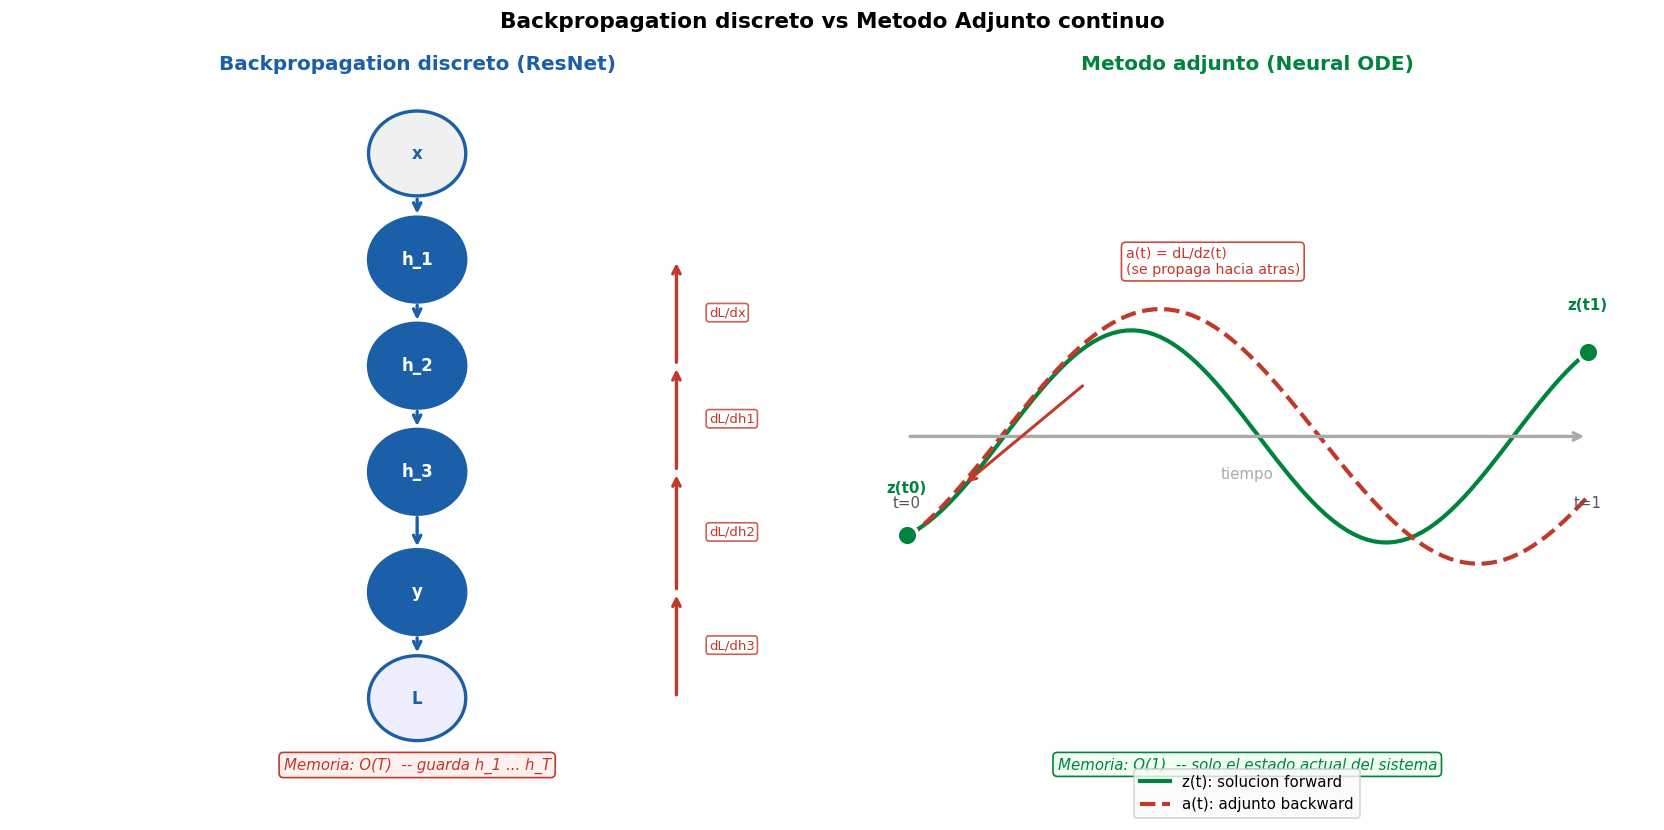

In [ ]:
# [OK] Visualizar la analogia: backpropagation discreto vs metodo adjunto

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white"); ax.axis("off")

# ── Panel izquierdo: Backprop discreto ───────────────────────
ax = axes[0]
ax.set_title("Backpropagation discreto (ResNet)", fontsize=12,
             fontweight="bold", color=AZUL, pad=8)

nodos_fwd = [(0.5, 0.90, "x"),   (0.5, 0.75, "h_1"),
             (0.5, 0.60, "h_2"), (0.5, 0.45, "h_3"), (0.5, 0.28, "y"), (0.5, 0.13, "L")]
for i, (x, y, lbl) in enumerate(nodos_fwd):
    fc = AZUL if 0 < i < 5 else ("#eef" if i == 5 else "#f0f0f0")
    tc = "white" if 0 < i < 5 else AZUL
    ax.add_patch(plt.Circle((x, y), 0.06, transform=ax.transAxes,
                             facecolor=fc, edgecolor=AZUL, linewidth=2, zorder=3))
    ax.text(x, y, lbl, ha="center", va="center", fontsize=10,
            fontweight="bold", color=tc, transform=ax.transAxes)

# Flechas forward
for i in range(len(nodos_fwd)-1):
    y0 = nodos_fwd[i][1] - 0.06; y1 = nodos_fwd[i+1][1] + 0.06
    ax.annotate("", xy=(0.5, y1), xytext=(0.5, y0), xycoords="axes fraction",
                 arrowprops=dict(arrowstyle="->", color=AZUL, lw=2))

# Flechas backward (gradientes)
grad_lbls = ["dL/dh3", "dL/dh2", "dL/dh1", "dL/dx"]
for i in range(4):
    y_from = nodos_fwd[5-i][1]
    y_to   = nodos_fwd[4-i][1]
    ax.annotate("", xy=(0.82, y_to), xytext=(0.82, y_from), xycoords="axes fraction",
                 arrowprops=dict(arrowstyle="->", color=ROJO, lw=2))
    ax.text(0.86, (y_from+y_to)/2, grad_lbls[i], ha="left", va="center",
            fontsize=8, color=ROJO, transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor=ROJO, alpha=0.8))

ax.text(0.5, 0.03, "Memoria: O(T)  -- guarda h_1 ... h_T",
        ha="center", fontsize=9, color=ROJO, style="italic", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff0f0", edgecolor=ROJO))

# ── Panel derecho: Metodo adjunto ─────────────────────────────
ax = axes[1]
ax.set_title("Metodo adjunto (Neural ODE)", fontsize=12,
             fontweight="bold", color=VERDE, pad=8)

# Eje de tiempo
ax.annotate("", xy=(0.92, 0.5), xytext=(0.08, 0.5), xycoords="axes fraction",
             arrowprops=dict(arrowstyle="->", color="#aaa", lw=2))
ax.text(0.5, 0.44, "tiempo", ha="center", fontsize=9, color="#aaa",
        transform=ax.transAxes)
ax.text(0.08, 0.40, "t=0", ha="center", fontsize=9, color="#555", transform=ax.transAxes)
ax.text(0.92, 0.40, "t=1", ha="center", fontsize=9, color="#555", transform=ax.transAxes)

# Curva forward z(t)
t_c = np.linspace(0.08, 0.92, 100)
z_c = 0.5 + 0.15*np.sin(t_c*10 - 2)
ax.plot(t_c, z_c, color=VERDE, linewidth=2.5, transform=ax.transAxes,
        label="z(t): solucion forward")

# Nodos t0 y t1
ax.scatter([0.08, 0.92], [z_c[0], z_c[-1]], s=150, color=VERDE,
           zorder=5, edgecolors="white", linewidths=2, transform=ax.transAxes)
ax.text(0.08, z_c[0]+0.06, "z(t0)", ha="center", fontsize=9, color=VERDE,
        fontweight="bold", transform=ax.transAxes)
ax.text(0.92, z_c[-1]+0.06, "z(t1)", ha="center", fontsize=9, color=VERDE,
        fontweight="bold", transform=ax.transAxes)

# Curva adjunta a(t)
a_c = 0.5 - 0.18*np.cos(t_c*8)
ax.plot(t_c, a_c, color=ROJO, linewidth=2.5, linestyle="--",
        transform=ax.transAxes, label="a(t): adjunto backward")
ax.annotate("", xy=(0.15, a_c[8]), xytext=(0.30, a_c[20]), xycoords="axes fraction",
             arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.8))
ax.text(0.35, 0.73, "a(t) = dL/dz(t)\n(se propaga hacia atras)", ha="left",
        fontsize=8.5, color=ROJO, transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=ROJO, alpha=0.9))

ax.set_xlim(0, 1); ax.set_ylim(0.1, 0.95)
ax.legend(fontsize=9, loc="lower center", bbox_to_anchor=(0.5, -0.05))
ax.text(0.5, 0.03, "Memoria: O(1)  -- solo el estado actual del sistema",
        ha="center", fontsize=9, color=VERDE, style="italic", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0fff0", edgecolor=VERDE))

plt.suptitle("Backpropagation discreto vs Metodo Adjunto continuo",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


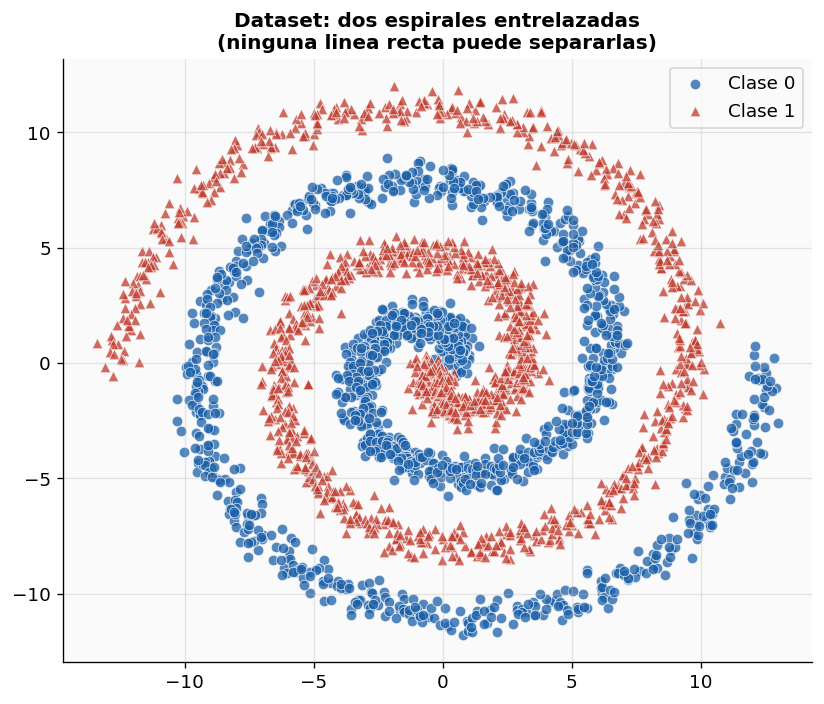

Este es el problema favorito para mostrar la ventaja de los modelos continuos:
la espiral es una curva en el espacio de fases -- como las del NB01.


In [ ]:
# [OK] Dataset: dos espirales (problema clasico no linealmente separable)
# Es el mismo tipo de problema que XOR pero en 2D y mas complejo.
# Lo usaremos primero para visualizar lo que aprende una Neural ODE.

def generar_espirales(n=20000, ruido=0.3, seed=42):
    rng = np.random.default_rng(seed)
    n_cada = n // 2
    def espiral(n, delta_t, ruido):
        t = np.linspace(0.5, 4*np.pi, n)
        x = t * np.cos(t + delta_t) + rng.normal(0, ruido, n)
        y = t * np.sin(t + delta_t) + rng.normal(0, ruido, n)
        return np.stack([x, y], axis=1)
    X0 = espiral(n_cada, 0, ruido)
    X1 = espiral(n_cada, np.pi, ruido)
    X  = np.vstack([X0, X1]).astype("float32")
    y  = np.array([0]*n_cada + [1]*n_cada, dtype="float32")
    return X, y

X_spiral, y_spiral = generar_espirales(n=3000, ruido=0.4)

fig, ax = plt.subplots(figsize=(7, 6))
for cls, color, marker in [(0, AZUL, "o"), (1, ROJO, "^")]:
    mask = y_spiral == cls
    ax.scatter(X_spiral[mask,0], X_spiral[mask,1], c=color, marker=marker,
               s=40, alpha=0.75, edgecolors="white", linewidths=0.5,
               label=f"Clase {cls}")
ax.set_title("Dataset: dos espirales entrelazadas\n"
             "(ninguna linea recta puede separarlas)", fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print("Este es el problema favorito para mostrar la ventaja de los modelos continuos:")
print("la espiral es una curva en el espacio de fases -- como las del NB01.")


## 4. La red $f_\theta$: la funcion que define la dinamica

En una Neural ODE, la red neuronal no transforma directamente la entrada en la salida.
En cambio, **define la derivada** del estado oculto:

$$\frac{d\mathbf{z}(t)}{dt} = f_\theta(\mathbf{z}(t),\, t)$$

La red $f_\theta$ puede ser cualquier arquitectura. La unica restriccion:
su **entrada y salida deben tener la misma forma** (porque define una derivada).

El estado $\mathbf{z}(t)$ empieza en $\mathbf{z}(0) = $ proyeccion de la entrada,
y el solver integra la EDO hasta $t=1$ para obtener la representacion final.

```
entrada x
    |
    v  [capa de proyeccion: x -> z(0)]
   z(0)
    |
    v  [ODESolve: dz/dt = f_theta(z,t), de t=0 a t=1]
   z(1)
    |
    v  [capa de clasificacion: z(1) -> logits]
  salida
```


In [ ]:
# [Ejercicio 1] Implementar la red de dinamica f_theta
#
# f_theta debe recibir z (estado actual) y t (tiempo)
# y retornar dz/dt (la derivada) -- con la MISMA forma que z.

class RedDinamica(keras.layers.Layer):
    """
    La red f_theta que define dz/dt = f_theta(z, t).
    Entrada:  z de forma (batch, dim)
    Salida:  dz/dt de forma (batch, dim)  <- misma forma
    """
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        # Red con capas densas que transforma z -> dz/dt
        # Nota: la dimension de entrada Y salida son iguales (dim)
        self.net = keras.Sequential([
            keras.layers.Input(shape=(dim+1,)),
            keras.layers.Dense(64, activation="tanh"),
            keras.layers.Dense(64, activation="tanh"),
            keras.layers.Dense(dim),    # <- sin activacion: puede ser positivo o negativo
        ])

    def call(self, z, t):
        """
        z: estado actual, forma (batch, dim)
        t: tiempo actual, escalar
        Retorna: dz/dt, forma (batch, dim)
        """
        # ================================================
        # [Ejercicio] Completa el forward pass.
        # Pista: la red recibe [z, t] concatenados.
        # Paso 1: crear t_vec con la misma forma que z[:,0:1]
        #         t_vec = tf.ones((tf.shape(z)[0], 1)) * t
        # Paso 2: concatenar z y t_vec en axis=-1
        #         entrada = tf.concat([z, t_vec], axis=-1)
        # Paso 3: pasar por self.net
        # ================================================
        t_vec   = t_vec = tf.ones((tf.shape(z)[0], 1)) * t  # <- forma: (batch, 1), valor: t
        entrada = entrada = tf.concat([z, t_vec], axis=-1)  # <- concatenacion de z y t_vec
        return self.net(entrada) if entrada is not None else None


# Verificacion
f_test = RedDinamica(dim=2)
z_test = tf.random.normal((4, 2))
try:
    dz = f_test(z_test, t=0.5)
    print(f"Entrada z:      {z_test.shape}")
    print(f"Salida dz/dt:   {dz.shape}   (debe ser igual a z)")
    if dz is not None and dz.shape == z_test.shape:
        print("[OK] f_theta implementada correctamente.")
except Exception as e:
    print(f"[!] {e}")


Entrada z:      (4, 2)
Salida dz/dt:   (4, 2)   (debe ser igual a z)
[OK] f_theta implementada correctamente.


In [ ]:
# [OK] Implementar ODESolve con RK4 diferenciable
# Usamos RK4 porque lo conocemos del NB01.
# La clave: todo el calculo esta dentro de tf.GradientTape
# para que TensorFlow pueda diferenciarlo.

def odesolve_rk4(f, z0, t0=0.0, t1=1.0, n_pasos=10):
    """
    Integra dz/dt = f(z, t) de t0 a t1 con RK4.

    f     : RedDinamica (callable: (z, t) -> dz/dt)
    z0    : estado inicial, forma (batch, dim)
    t0,t1 : tiempos inicial y final
    n_pasos: numero de pasos de RK4

    Retorna: z(t1) de forma (batch, dim)
    """
    h = (t1 - t0) / n_pasos
    z = z0
    t = t0
    for _ in range(n_pasos):
        k1 = f(z, t=t)
        k2 = f(z + (h/2)*k1, t = t + h/2)
        k3 = f(z + (h/2)*k2, t = t + h/2)
        k4 = f(z + h*k3, t = t + h)
        z  = z + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t  = t + h
    return z


# Prueba rapida
f_prueba = RedDinamica(dim=2)
z0_p = tf.random.normal((3, 2))
z1_p = odesolve_rk4(f_prueba, z0_p)
print(f"z(t=0): {z0_p.shape}  ->  z(t=1): {z1_p.shape}")
print("[OK] ODESolve con RK4 funciona.")


z(t=0): (3, 2)  ->  z(t=1): (3, 2)
[OK] ODESolve con RK4 funciona.


In [ ]:
# [OK] Ensamblar la Neural ODE completa

class NeuralODE(keras.Model):
    """
    Neural ODE para clasificacion binaria.
    Estructura:
      1. Proyeccion: entrada -> z(0)  [espacio latente]
      2. ODESolve:   dz/dt = f_theta(z, t), de t=0 a t=1
      3. Clasificacion: z(1) -> probabilidades
    """
    def __init__(self, dim_entrada, dim_latente=8, n_clases=1, n_pasos=10, **kwargs):
        super().__init__(**kwargs)
        self.n_pasos = n_pasos

        # Capa de proyeccion
        self.proyeccion = keras.layers.Dense(dim_latente, activation="tanh")

        # La red de dinamica (el corazon de la Neural ODE)
        self.f_theta = RedDinamica(dim=dim_latente)

        # Capa de clasificacion
        self.clasificador = keras.layers.Dense(n_clases, activation="sigmoid") # Es sigmoide porque asigma probabilidades

    def call(self, x, training=False):
        # Paso 1: proyectar la entrada al espacio latente
        z0 = self.proyeccion(x)

        # Paso 2: integrar la EDO de t=0 a t=1
        z1 = odesolve_rk4(self.f_theta, z0, t0=0.0, t1=1.0, n_pasos=self.n_pasos)

        # Paso 3: clasificar desde el estado final
        return self.clasificador(z1)


# Construir el modelo
node = NeuralODE(dim_entrada=2, dim_latente=8, n_clases=1, n_pasos=10)

# Compilar con binary crossentropy para clasificacion binaria
node.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Probar la arquitectura
y_prueba = node(tf.constant(X_spiral[:4]))
print(f"Entrada:   {X_spiral[:4].shape}")
print(f"Salida:    {y_prueba.shape}  (probabilidad clase 1)")
node.summary()


Entrada:   (4, 2)
Salida:    (4, 1)  (probabilidad clase 1)


Model: "neural_ode_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (4, 8)                 │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ red_dinamica_9 (RedDinamica)    │ ?                      │         5,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (4, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,353 (20.91 KB)

 Trainable params: 5,353 (20.91 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando Neural ODE en espirales...
Entrenamiento: 69.1s   Exactitud val: 98.8%


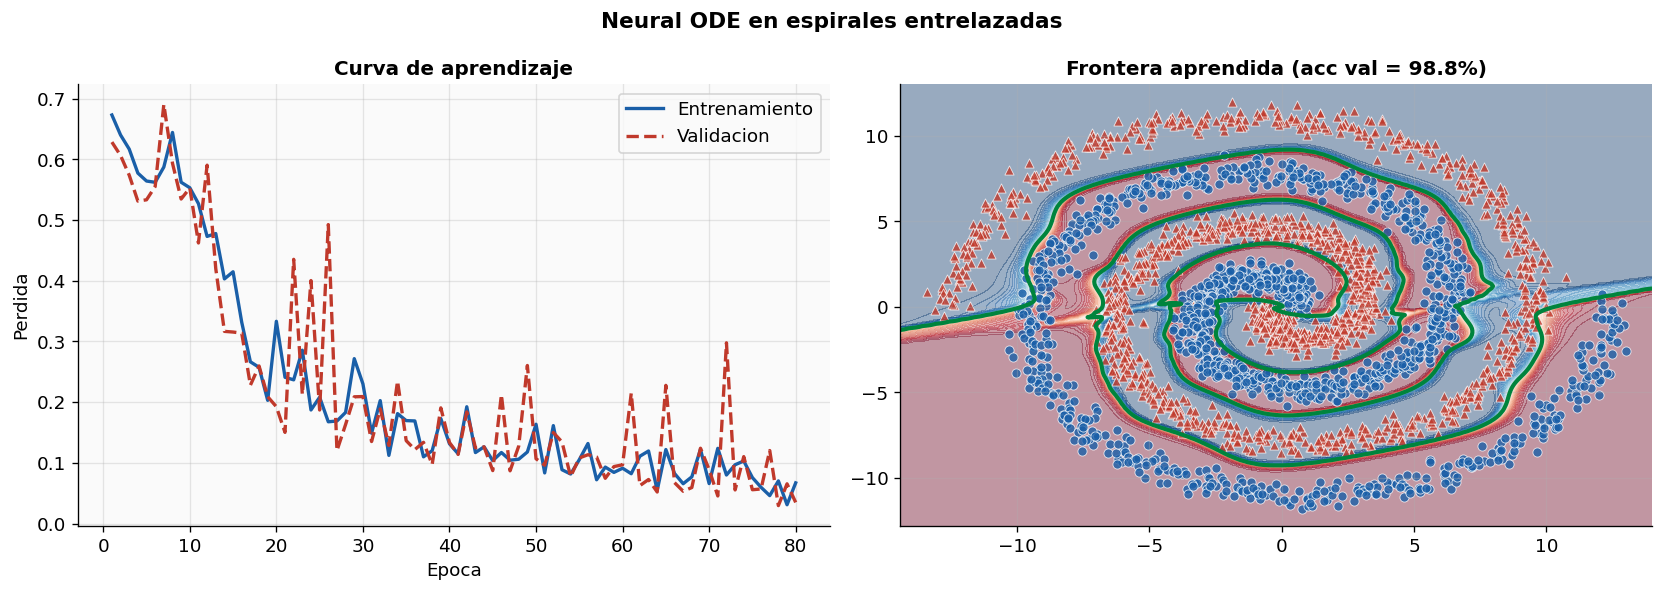

In [ ]:
# [OK] Entrenar la Neural ODE en el dataset de espirales

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_spiral, y_spiral, test_size=0.2, random_state=42)

print("Entrenando Neural ODE en espirales...")
t0 = time.time()

historia = node.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    verbose=0,
)

dt = time.time() - t0
acc_val_final = historia.history["val_accuracy"][-1]
print(f"Entrenamiento: {dt:.1f}s   Exactitud val: {acc_val_final:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de aprendizaje
ep = range(1, len(historia.history["loss"])+1)
axes[0].plot(ep, historia.history["loss"],     color=AZUL, lw=2, label="Entrenamiento")
axes[0].plot(ep, historia.history["val_loss"], color=ROJO, lw=2, ls="--", label="Validacion")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Perdida")
axes[0].set_title("Curva de aprendizaje", fontsize=12, fontweight="bold")
axes[0].legend()

# Frontera de decision aprendida
x1r = np.linspace(X_spiral[:,0].min()-1, X_spiral[:,0].max()+1, 200)
x2r = np.linspace(X_spiral[:,1].min()-1, X_spiral[:,1].max()+1, 200)
xx1, xx2 = np.meshgrid(x1r, x2r)
grid = np.c_[xx1.ravel(), xx2.ravel()].astype("float32")
Z = node.predict(grid, verbose=0).reshape(xx1.shape)

axes[1].contourf(xx1, xx2, Z, levels=50, cmap="RdBu", alpha=0.4)
axes[1].contour(xx1,  xx2, Z, levels=[0.5], colors=[VERDE], linewidths=2.5)
for cls, color, marker in [(0, AZUL, "o"), (1, ROJO, "^")]:
    mask = y_spiral == cls
    axes[1].scatter(X_spiral[mask,0], X_spiral[mask,1], c=color, marker=marker,
                    s=30, alpha=0.8, edgecolors="white", linewidths=0.5)
axes[1].set_title(f"Frontera aprendida (acc val = {acc_val_final:.1%})",
                   fontsize=12, fontweight="bold")

plt.suptitle("Neural ODE en espirales entrelazadas", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


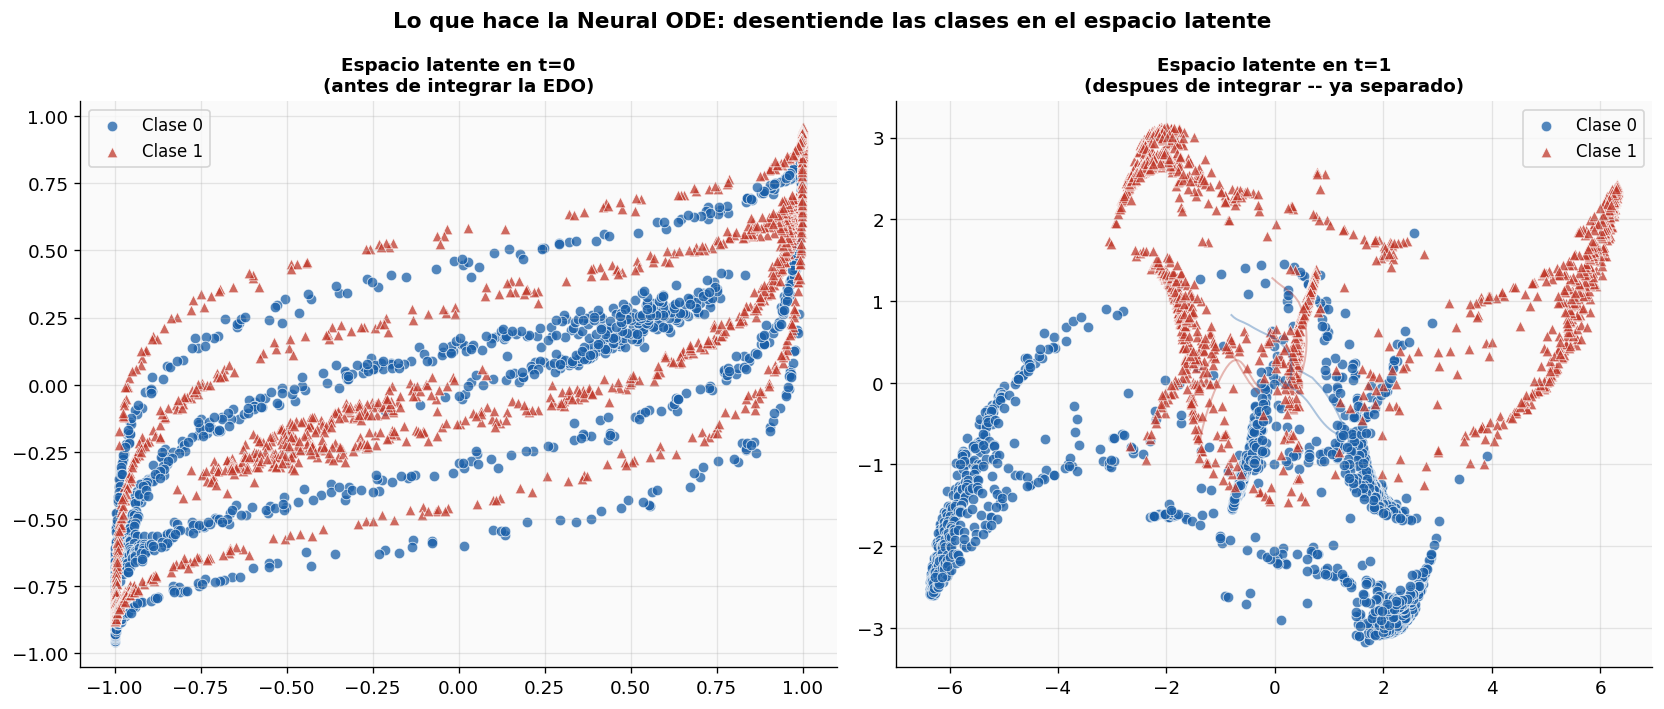

La Neural ODE aprende un flujo en el espacio latente que
lleva cada clase a una region separada -- como un campo vectorial
que organiza los datos. Esto es el diagrama de fase del NB01, aplicado
al aprendizaje de representaciones.


In [ ]:
# [OK] Visualizar las trayectorias en el espacio latente
# Esta es la intuicion clave de la Neural ODE:
# el solver "desenreda" las espirales en el espacio latente.

def obtener_trayectoria(modelo, x, n_pasos=20):
    """Calcula z(t) para t en [0,1] para una muestra x."""
    z = modelo.proyeccion(tf.constant(x[np.newaxis], dtype="float32"))
    tray = [z.numpy()[0]]
    h    = 1.0 / n_pasos
    for i in range(n_pasos):
        t  = i * h
        k1 = modelo.f_theta(z, t=t)
        k2 = modelo.f_theta(z + (h/2)*k1,t= t + h/2)
        k3 = modelo.f_theta(z + (h/2)*k2, t=t + h/2)
        k4 = modelo.f_theta(z + h*k3,t= t + h)
        z  = z + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        tray.append(z.numpy()[0])
    return np.array(tray)


# Elegir algunas muestras de cada clase
np.random.seed(5)
idx0 = np.where(y_spiral == 0)[0][:6]
idx1 = np.where(y_spiral == 1)[0][:6]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Proyectar TODAS las muestras al inicio y al final
z0_all = node.proyeccion(tf.constant(X_spiral, dtype="float32")).numpy()
z1_all = odesolve_rk4(node.f_theta, tf.constant(z0_all, dtype="float32")).numpy()

for ax_idx, (zs, titulo) in enumerate([
    (z0_all, "Espacio latente en t=0\n(antes de integrar la EDO)"),
    (z1_all, "Espacio latente en t=1\n(despues de integrar -- ya separado)"),
]):
    ax = axes[ax_idx]
    for cls, color, marker in [(0, AZUL, "o"), (1, ROJO, "^")]:
        mask = y_spiral == cls
        ax.scatter(zs[mask,0], zs[mask,1], c=color, marker=marker,
                   s=40, alpha=0.75, edgecolors="white", linewidths=0.5,
                   label=f"Clase {cls}")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.legend(fontsize=10)

# Dibujar algunas trayectorias
for idx, color in [(idx0, AZUL), (idx1, ROJO)]:
    for i in idx[:3]:
        tray = obtener_trayectoria(node, X_spiral[i])
        if tray.shape[1] >= 2:
            axes[1].plot(tray[:,0], tray[:,1], color=color,
                          alpha=0.35, linewidth=1.2)

plt.suptitle("Lo que hace la Neural ODE: desentiende las clases en el espacio latente",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("La Neural ODE aprende un flujo en el espacio latente que")
print("lleva cada clase a una region separada -- como un campo vectorial")
print("que organiza los datos. Esto es el diagrama de fase del NB01, aplicado")
print("al aprendizaje de representaciones.")


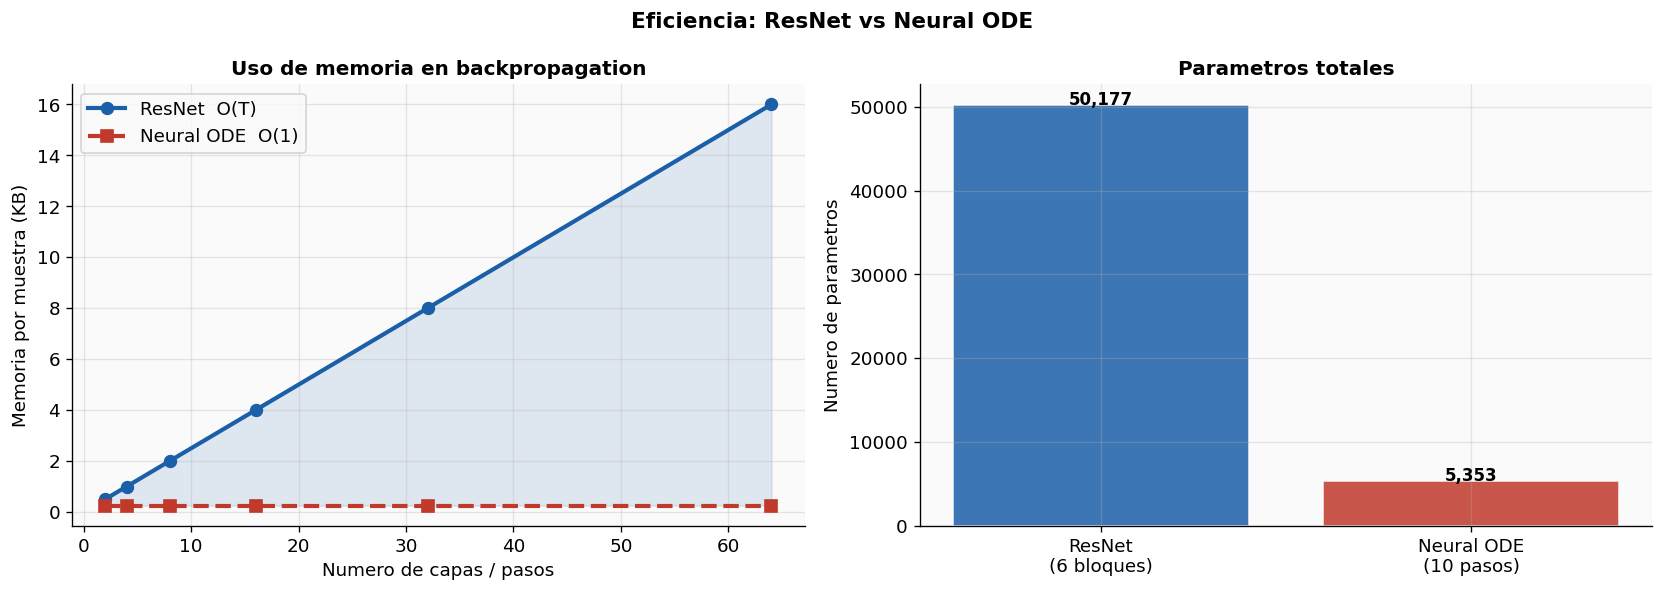

ResNet (6 bloques): 50,177 parametros
Neural ODE:         5,353 parametros


In [ ]:
# [Ejercicio 2] Comparar el uso de memoria: ResNet vs Neural ODE

# ── Construir una ResNet equivalente ─────────────────────────
def construir_resnet_espiral(dim=2, h=64, n_bloques=6):
    class Bloque(keras.layers.Layer):
        def __init__(self, u, **kw):
            super().__init__(**kw)
            self.d1 = keras.layers.Dense(u, activation="tanh")
            self.d2 = keras.layers.Dense(u)
        def call(self, x):
            return tf.nn.tanh(x + self.d2(self.d1(x)))

    entradas = keras.Input(shape=(dim,))
    x = keras.layers.Dense(h, activation="tanh")(entradas)
    for _ in range(n_bloques):
        x = Bloque(h)(x)
    sal = keras.layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(entradas, sal, name="ResNet_espiral")


# Estimar memoria en funcion de la profundidad
# ResNet: guarda activacion de cada capa (h*4 bytes)
# Neural ODE: guarda solo el estado actual

profundidades  = [2, 4, 8, 16, 32, 64]
mem_resnet     = [T * 64 * 4 / 1024 for T in profundidades]     # KB por muestra
mem_neural_ode = [64 * 4 / 1024 for _ in profundidades]         # constante

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(profundidades, mem_resnet, color=AZUL, lw=2.5,
              marker="o", markersize=7, label="ResNet  O(T)")
axes[0].plot(profundidades, mem_neural_ode, color=ROJO, lw=2.5,
              marker="s", markersize=7, linestyle="--", label="Neural ODE  O(1)")
axes[0].set_xlabel("Numero de capas / pasos", fontsize=11)
axes[0].set_ylabel("Memoria por muestra (KB)", fontsize=11)
axes[0].set_title("Uso de memoria en backpropagation", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].fill_between(profundidades, mem_resnet, mem_neural_ode,
                      alpha=0.12, color=AZUL, label="Ventaja de la Neural ODE")

# Params
params_node   = node.count_params()
resnet_spi    = construir_resnet_espiral(n_bloques=6)
params_resnet = resnet_spi.count_params()

axes[1].bar(["ResNet\n(6 bloques)", "Neural ODE\n(10 pasos)"],
             [params_resnet, params_node],
             color=[AZUL, ROJO], alpha=0.85, edgecolor="white")
for i, (nom, p) in enumerate([("ResNet", params_resnet), ("NODE", params_node)]):
    axes[1].text(i, p+30, f"{p:,}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Numero de parametros", fontsize=11)
axes[1].set_title("Parametros totales", fontsize=12, fontweight="bold")

plt.suptitle("Eficiencia: ResNet vs Neural ODE", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"ResNet (6 bloques): {params_resnet:,} parametros")
print(f"Neural ODE:         {params_node:,} parametros")

# ================================================
# [Ejercicio] Reflexion:
# 1. Por que la memoria de ResNet crece con T pero la de Neural ODE no?
# 2. Que es el metodo adjunto en terminos de como reconstruye el pasado?
# 3. La Neural ODE tiene menos parametros que ResNet. Como puede
#    ser igual o mas precisa? (Pista: piensa en el paso adaptativo)
# ================================================


1. Por que en la NeuralODE se calcula única vez, mientras que la ResNet hace calculos con cada iteración.

2. El método adjunto busca ahorra memoria pues no guarda cada uno de los errores si no que teremina realizando un PVI inverso donde calcula los errores cuando se decuelve,

3. Mientras que ResNet tiene un número fijo de capas, NeuralODE usa un solver que ajusta la complejidad del cálculo para cada entrada.

In [ ]:
# [OK] Neural ODE en MNIST: comparacion con el NB05

(X_tr2d, y_tr_m), (X_te2d, y_te_m) = keras.datasets.mnist.load_data()
X_tr_m = X_tr2d.astype("float32").reshape(-1, 784) / 255.0
X_te_m = X_te2d.astype("float32").reshape(-1, 784) / 255.0

class NeuralODE_MNIST(keras.Model):
    def __init__(self, n_pasos=6, dim_latente=64, **kwargs):
        super().__init__(**kwargs)
        self.proyeccion  = keras.layers.Dense(dim_latente, activation="tanh")
        self.f_theta     = RedDinamica(dim=dim_latente)
        self.clasificador = keras.Sequential([
            keras.layers.Dense(dim_latente, activation="relu"),
            keras.layers.Dense(10, activation="softmax"),
        ])
        self.n_pasos = n_pasos

    def call(self, x, training=False):
        z0 = self.proyeccion(x)
        z1 = odesolve_rk4(self.f_theta, z0, n_pasos=self.n_pasos)
        return self.clasificador(z1)

tf.random.set_seed(42)
node_mnist = NeuralODE_MNIST(n_pasos=6, dim_latente=128)
node_mnist.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Entrenando Neural ODE en MNIST (puede tomar unos minutos)...")
t0 = time.time()
hist_node = node_mnist.fit(
    X_tr_m, y_tr_m, epochs=10, batch_size=256,
    validation_data=(X_te_m, y_te_m), verbose=1,
)
dt = time.time() - t0
_, acc_node = node_mnist.evaluate(X_te_m, y_te_m, verbose=0)
print(f"\nNeural ODE MNIST: acc={acc_node:.4f}  params={node_mnist.count_params():,}  t={dt:.1f}s")


Entrenando Neural ODE en MNIST (puede tomar unos minutos)...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.9003 - loss: 0.3412 - val_accuracy: 0.9434 - val_loss: 0.1769
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9559 - loss: 0.1444 - val_accuracy: 0.9602 - val_loss: 0.1298
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9677 - loss: 0.1029 - val_accuracy: 0.9659 - val_loss: 0.1082
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9751 - loss: 0.0806 - val_accuracy: 0.9705 - val_loss: 0.0981
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9792 - loss: 0.0664 - val_accuracy: 0.9706 - val_loss: 0.1009
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9833 - loss: 0.0539 - val_accuracy: 0.9717 - val_loss: 0.0964
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9678 - val_loss: 0.1132
Epoch 8/10
235/235 ━━━━━━━━━━

In [ ]:
# [OK] Tabla final: todos los modelos incluyendo la Neural ODE

# Resultados del NB05 (aproximados)
res_nb05 = {
    "MLP":    (1.60, 167000),
    "ResNet": (0.61, 206000),
    "RK-Net": (0.47, 220000),
}

err_node_nuestro = (1 - acc_node) * 100
params_node_m    = node_mnist.count_params()

print("=" * 70)
print("  Tabla Final: de MLP a Neural ODE")
print("=" * 70)
header = "{:<14} {:>16} {:>12} {:>10}".format(
    "Modelo", "Error en test (%)", "Parametros", "Tipo")
print(header)
print("-" * 70)
for nombre, (err, params) in res_nb05.items():
    tipo = "Euler" if nombre == "ResNet" else ("RK4" if nombre == "RK-Net" else "ninguno")
    fila = "{:<14} {:>14.2f}%  {:>11,}  {}".format(nombre, err, params, tipo)
    print(fila)
fila_node = "{:<14} {:>14.2f}%  {:>11,}  {}".format(
    "Neural ODE", err_node_nuestro, params_node_m, "Solver adaptativo")
print(fila_node)
print("=" * 70)
print()
print("La tendencia del paper se mantiene:")
print("mayor orden de integracion -> mejor uso de los parametros.")


  Tabla Final: de MLP a Neural ODE
Modelo         Error en test (%)   Parametros       Tipo
----------------------------------------------------------------------
MLP                      1.60%      167,000  ninguno
ResNet                   0.61%      206,000  Euler
RK-Net                   0.47%      220,000  RK4
Neural ODE               3.48%      139,082  Solver adaptativo

La tendencia del paper se mantiene:
mayor orden de integracion -> mejor uso de los parametros.


## 5. Resumen: el Algoritmo 1 y lo que hemos construido

### Lo que aprendimos

| Concepto | Clave |
|----------|-------|
| **Adjunto** $a(t)$ | El gradiente continuo: $\partial L / \partial \mathbf{z}(t)$ -- como $\delta_t$ en backprop |
| **Dinamicas aumentadas** | Sistema de EDOs que propaga z, a, y dL/dtheta hacia atras simultaneamente |
| **Memoria O(1)** | El adjunto reconstruye el pasado resolviendo la EDO hacia atras |
| **Vector-Jacobiano** | TensorFlow calcula $a^T (\partial f / \partial z)$ con `tape.gradient` sin el Jacobiano completo |
| **Trayectorias latentes** | La Neural ODE aprende un flujo que organiza las clases en el espacio latente |

---

### La analogia completa: backpropagation vs metodo adjunto

| Backpropagation (discreto) | Metodo adjunto (continuo) |
|---------------------------|---------------------------|
| Propaga $\delta_t$ capa por capa | Propaga $a(t)$ resolviendo una EDO |
| $\delta_{t-1} = \delta_t \cdot W_t^T$ | $da/dt = -a(t)^T (\partial f / \partial z)$ |
| Guarda todas las activaciones: O(T) | Solo el estado actual: O(1) |
| Paso fijo (una capa = un paso) | Paso adaptativo segun dificultad |

---

### El recorrido completo de la serie

```
NB01: Neurona biologica -> FitzHugh-Nagumo -> RK4 -> Diagrama de fases
NB02: McCulloch-Pitts -> Perceptron -> Limites del modelo lineal
NB03: Gradiente -> Backpropagation -> Keras -> Flatten/Padding
NB04: MNIST -> 97%+ exactitud -> Lo que aprende la primera capa
NB05: ResNet=Euler -> RK-Net=RK4 -> Tabla 1 del paper
NB06: Estado adjunto -> Dinamicas aumentadas -> Neural ODE real
```

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
